In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random


In [3]:
data_dir = "../../data_train/kaggle/working/data/train"
sample_size = 100  # nombre d’images à analyser


In [4]:
all_classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
all_images = []
for cls in all_classes:
    cls_dir = os.path.join(data_dir, cls)
    imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith('.png')]
    all_images.extend(imgs)
print(f"Total images trouvées : {len(all_images)}")


Total images trouvées : 14563


In [5]:
sample_images = random.sample(all_images, min(sample_size, len(all_images)))


In [6]:
pixels = []
for img_path in sample_images:
    img = Image.open(img_path).convert('L')  # 'L' pour grayscale
    arr = np.array(img).flatten()
    pixels.append(arr)
pixels = np.concatenate(pixels)
print(f"Pixels shape: {pixels.shape}")


Pixels shape: (104857600,)


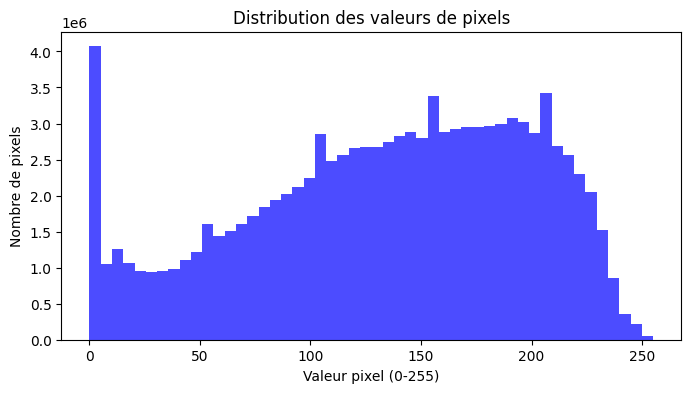

In [7]:
plt.figure(figsize=(8,4))
plt.hist(pixels, bins=50, color='blue', alpha=0.7)
plt.title("Distribution des valeurs de pixels")
plt.xlabel("Valeur pixel (0-255)")
plt.ylabel("Nombre de pixels")
plt.show()

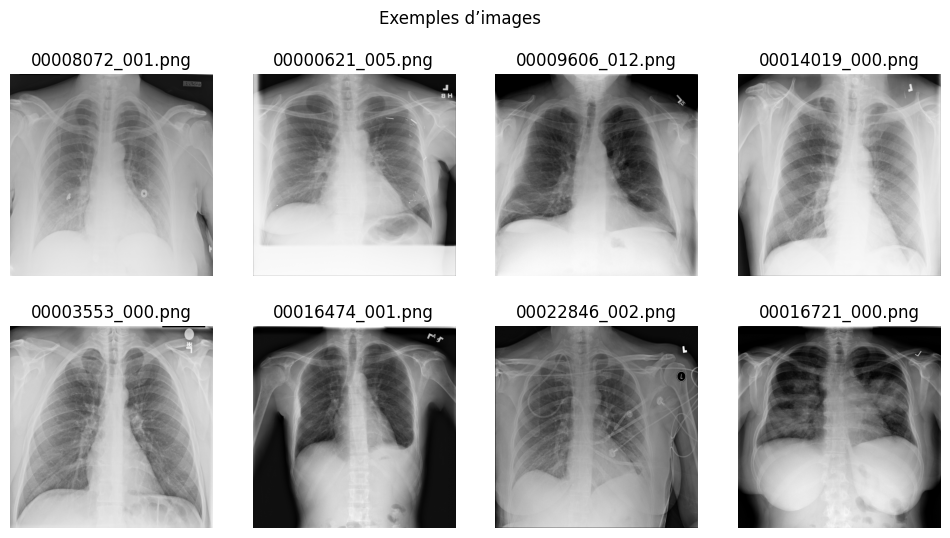

In [8]:
plt.figure(figsize=(12,6))
for i, img_path in enumerate(sample_images[:8]):
    img = Image.open(img_path)
    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(os.path.basename(img_path))
plt.suptitle("Exemples d’images")
plt.show()

Pas besoin de faire des rotation d'images, ou de changement de résolution car les radio sont toujours faite de la meme maniere


In [9]:
mean = np.mean(pixels)
std = np.std(pixels)
print(f"Moyenne des pixels : {mean:.2f}")
print(f"Ecart-type des pixels : {std:.2f}")

Moyenne des pixels : 133.76
Ecart-type des pixels : 64.12
